# Selected Graphs for Research Conference

## Prep

### Import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from   _Constants import *
from   _Functions import *

### Parameters

In [3]:
ERROR_PERCENTILE = 0.95     # Two tailed 95% Center Percentiles

## C by Area Graph

In [4]:
eps_test        = EPS_R[DIELECTRIC](MEASUREMENT_FREQ)
Cp_expected     = EPS_0 * eps_test * A / S * 1e12       # Change to pF
Cp_exp_by_diam  = get_expected_Cp_by_Diameter()         # diameter = m, cp_exp = F

y_range         = Cp_expected[-1] - Cp_expected[0]

In [5]:
Cp_df = pd.read_csv("../Data/Cp_by_Measurement.csv")
Cp_df.set_index(Cp_df.iloc[:, 0].values, inplace=True)
Cp_df.drop(columns=[Cp_df.columns[0]], inplace=True)

In [6]:
num_positions = len(Cp_df["pos"].unique())
num_wafers    = len(Cp_df["wafer_num"].unique())

### By Position

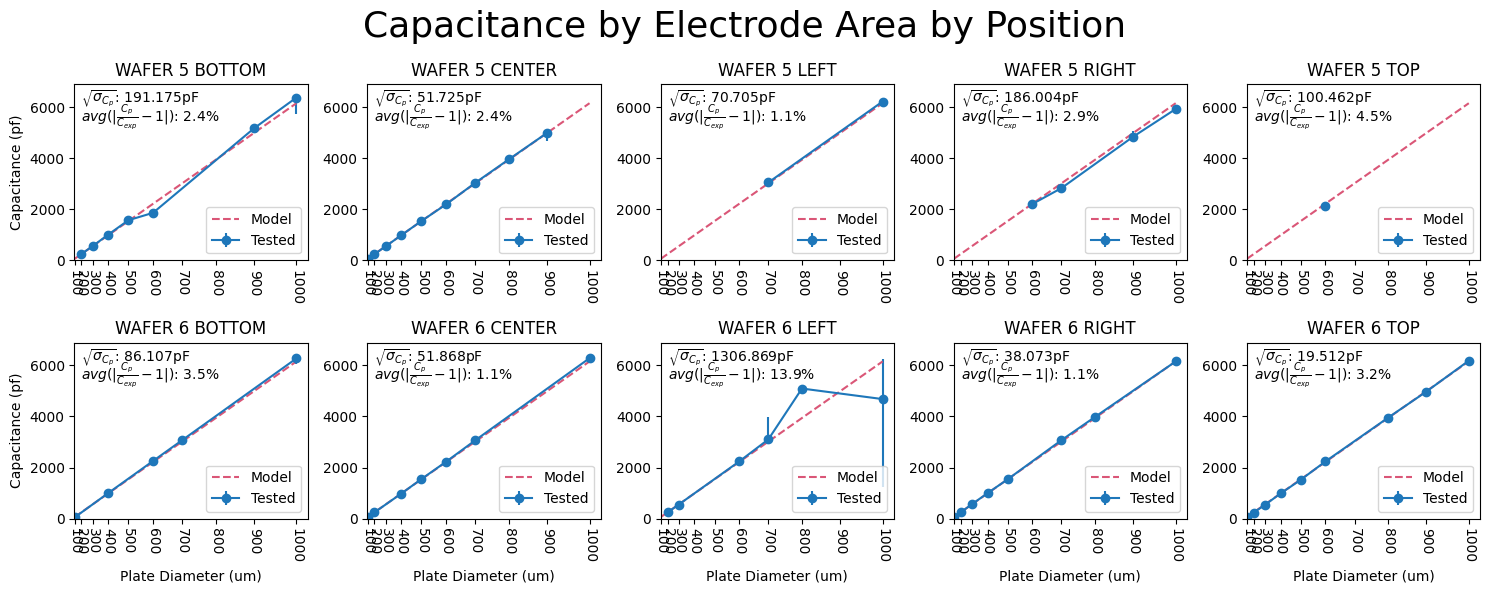

In [11]:
fig, ax = plt.subplots(ncols = num_positions, nrows = num_wafers, figsize=(num_positions * 3, num_wafers * 3)) # Roughly 300 px for each graph
fig.suptitle(f"Capacitance by Electrode Area by Position", size=26) #fontdict={"family": "Arial Unicode MS", "fontweight": "bold"})

# Loop through wafers (rows)
for i_waf, n_waf in enumerate(Cp_df["wafer_num"].unique()):
    Cp_this_waf = Cp_df.loc[Cp_df["wafer_num"] == n_waf]

    # Loop through positions (cols)
    for i_pos, pos in enumerate(Cp_this_waf["pos"].unique()):
        Cp_this_pos = Cp_this_waf.loc[Cp_this_waf["pos"] == pos]

        num_data_this_pos = Cp_this_pos.iloc[:, 6:].size;

        label       = f"WAFER {n_waf} {pos}"
        diams       = Cp_this_pos["cap_diam"].unique()
        areas       = np.pi * 0.25 * diams * diams
        Cps         = []
        Cps_err_lo  = []
        Cps_err_hi  = []
        mse         = 0
        avg_pc_diff = 0

        # Gather Capcitance, Percnetiles, MSE, and Absolute percente error from this subset.
        for diam in diams:
            data_this_diam = Cp_this_pos.loc[Cp_this_pos["cap_diam"] == diam].iloc[:, 6:].values
            Cps.append(np.median(data_this_diam))
            Cps_err_lo.append(np.quantile(data_this_diam,     (1 - ERROR_PERCENTILE) / 2))
            Cps_err_hi.append(np.quantile(data_this_diam, 1 - (1 - ERROR_PERCENTILE) / 2))

            mse += np.sum(np.square(data_this_diam - Cp_exp_by_diam[diam*1e-6]))
            avg_pc_diff += np.abs(np.sum(data_this_diam / Cp_exp_by_diam[diam*1e-6] - 1))

        # Normalize accumulators and convert units for plotting
        mse         /= num_data_this_pos
        sd           = np.sqrt(mse)

        avg_pc_diff *=  100 / num_data_this_pos

        sd          *=  1e12 # Display in pF
        diams       *=  1e-3 # Display in mm
        areas       *=  1e-6 # Display in square millimeters
        Cps          =  1e12 * np.array(Cps)
        Cps_err_lo   = -1e12 * np.array(Cps_err_lo) + Cps
        Cps_err_hi   =  1e12 * np.array(Cps_err_hi) - Cps

        # Plot data
        this_ax = ax[i_waf, i_pos]
        this_ax.set_title(label)
        this_ax.set_xlabel("Plate Diameter (um)") if i_waf == 1 else None
        this_ax.set_ylabel("Capacitance (pf)") if i_pos == 0 else None
        this_ax.set_ylim(0, Cp_expected[-1] * 1.12)
        this_ax.set_xlim(A[0]*1e6*0.9, A[-1]*1e6*1.05)
        this_ax.set_xticks(A*1e6, labels=[f"{round(d*1e6):d}" for d in D], rotation=-90)
        this_ax.errorbar(areas, Cps, yerr=[Cps_err_lo, Cps_err_hi], marker="o", color="#1e77ba", label="Tested")
        this_ax.plot(A*1e6, Cp_expected, linestyle="--", color="#da5677", label="Model")
        this_ax.text(A[1]*1e6, Cp_expected[0] + y_range*0.88, "$avg(|\\frac{C_{p}}{C_{exp}}-1|)$: " + f"{avg_pc_diff:.1f}%")
        this_ax.text(A[1]*1e6, Cp_expected[0] + y_range*1, "$\\sqrt{\\sigma_{C_{p}}}$: " + f"{sd:.3f}pF")
        this_ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(f"../Figures/MEDIAN_C_BY_A-POS.svg")

### By Wafer

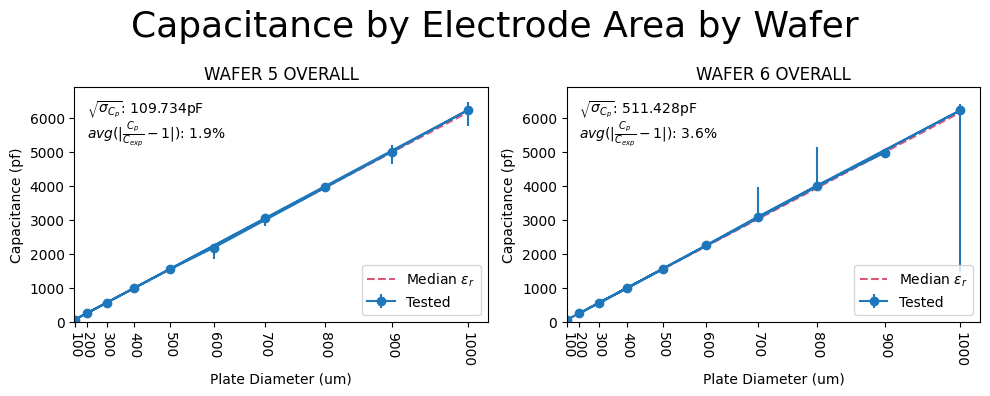

In [15]:
fig, ax = plt.subplots(ncols = num_wafers, nrows = 1, figsize=(num_wafers * 5, 1 * 4))
fig.suptitle(f"Capacitance by Electrode Area by Wafer", size=26)

# Loop through wafers (rows)
for i_waf, n_waf in enumerate(Cp_df["wafer_num"].unique()):
    Cp_this_waf = Cp_df.loc[Cp_df["wafer_num"] == n_waf]

    num_data_this_pos = Cp_this_waf.iloc[:, 6:].size;

    label       = f"WAFER {n_waf}"
    diams       = Cp_this_waf["cap_diam"].unique()
    areas       = np.pi * 0.25 * diams * diams
    Cps         = []
    Cps_err_lo  = []
    Cps_err_hi  = []
    mse         = 0
    avg_pc_diff = 0

    # Gather Capcitance, Percnetiles, MSE, and Absolute percente error from this subset.
    for diam in diams:
        data_this_diam = Cp_this_waf.loc[Cp_this_waf["cap_diam"] == diam].iloc[:, 6:].values
        Cps.append(np.median(data_this_diam))
        Cps_err_lo.append(np.quantile(data_this_diam,     (1 - ERROR_PERCENTILE) / 2))
        Cps_err_hi.append(np.quantile(data_this_diam, 1 - (1 - ERROR_PERCENTILE) / 2))

        mse += np.sum(np.square(data_this_diam - Cp_exp_by_diam[diam*1e-6]))
        avg_pc_diff += np.abs(np.sum(data_this_diam / Cp_exp_by_diam[diam*1e-6] - 1))

    # Normalize accumulators and convert units for plotting
    mse         /= num_data_this_pos
    sd           = np.sqrt(mse)

    avg_pc_diff *=  100 / num_data_this_pos

    sd          *=  1e12 # Display in pF
    diams       *=  1e-3 # Display in mm
    areas       *=  1e-6 # Display in square millimeters
    Cps          =  1e12 * np.array(Cps)
    Cps_err_lo   = -1e12 * np.array(Cps_err_lo) + Cps
    Cps_err_hi   =  1e12 * np.array(Cps_err_hi) - Cps

    # Plot data
    this_ax = ax[i_waf]
    this_ax.set_title(label + " OVERALL")
    this_ax.set_xlabel("Plate Diameter (um)")
    this_ax.set_ylabel("Capacitance (pf)")
    this_ax.set_ylim(0, Cp_expected[-1] * 1.12)
    this_ax.set_xlim(A[0]*1e6*0.9, A[-1]*1e6*1.05)
    this_ax.set_xticks(A*1e6, labels=[f"{round(d*1e6):d}" for d in D], rotation=-90)
    this_ax.errorbar(areas, Cps, yerr=[Cps_err_lo, Cps_err_hi], marker="o", color="#1e77ba", label="Tested")
    this_ax.plot(A*1e6, Cp_expected, linestyle="--", color="#da5677", label="Median $\\epsilon_{r}$")
    this_ax.text(A[1]*1e6, Cp_expected[0] + y_range*0.88, "$avg(|\\frac{C_{p}}{C_{exp}}-1|)$: " + f"{avg_pc_diff:.1f}%")
    this_ax.text(A[1]*1e6, Cp_expected[0] + y_range*1, "$\\sqrt{\\sigma_{C_{p}}}$: " + f"{sd:.3f}pF")
    this_ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(f"../Figures/MEDIAN_C_BY_A-WAF.svg")